# Practical Session 04a &mdash; The logistic model: from a score to a probability

**Companion to Lecture&nbsp;04 (Logistic Regression & Classification).** This is the first of four
practical notebooks that build logistic regression **from scratch in NumPy** and check every step
against scikit-learn:

| # | Notebook | Topic |
|---|----------|-------|
| **04a** | **the model** | **the sigmoid, odds/log-odds, the decision boundary (this notebook)** |
| 04b | training from scratch | cross-entropy, the gradient, gradient descent, convexity, $L_2$ |
| 04c | evaluation | confusion matrix, precision/recall/F1, ROC/AUC, thresholds, imbalance |
| 04d | multiclass | softmax from scratch, cross-entropy, decision regions, digits |

Linear regression predicted a **number**. Classification predicts a **category**: here a label
$y\in\{0,1\}$. The trick is to keep the familiar linear score $z=\mathbf{w}^\top\mathbf{x}+b$ but
**squash** it into a probability with the *sigmoid*. This notebook builds that link and draws the
picture it produces: a **linear decision boundary**.

> ⭐ **Key idea.** Logistic regression is a linear model on the **log-odds**: it computes the same
> linear score $z$, then maps it to a probability $p=\sigma(z)\in(0,1)$. Predicting the class is
> thresholding $p$ at $0.5$, i.e. asking the sign of $z$ &mdash; so the boundary is a straight line.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style                 # local styling helper (sibling file)
from nb_data import make_logistic_1d, make_logistic_2d  # synthetic data with KNOWN w, b

use_style("notes")
print("ready")

ready


## 1. Why not just fit a line to the 0/1 labels?

The tempting shortcut: run ordinary least squares on the labels $y\in\{0,1\}$ and threshold at
$0.5$. Two things break immediately &mdash; the fitted line leaves the interval $[0,1]$ (so it is
**not a probability**), and a single far point tilts it, dragging the threshold.

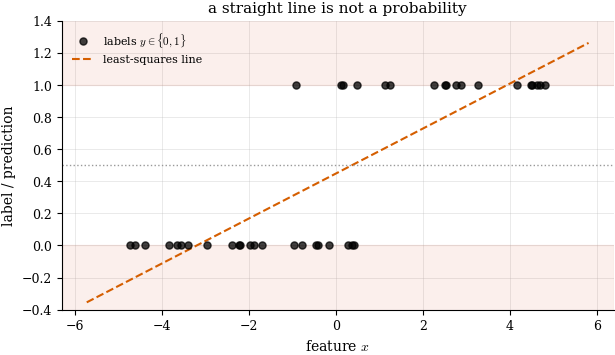

the line predicts values as high as 1.26 and as low as -0.35 -- not in [0,1]


In [2]:
x, y, w_true, b_true = make_logistic_1d(n=40, seed=1, w=1.8, b=0.0)

# ordinary least-squares line fit to the 0/1 labels
a, c = np.polyfit(x, y, 1)          # slope, intercept
xs = np.linspace(x.min() - 1, x.max() + 1, 200)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.scatter(x, y, s=26, alpha=0.75, zorder=3, label="labels $y\\in\\{0,1\\}$")
ax.plot(xs, a * xs + c, "--", color="#D55E00", label="least-squares line")
ax.axhspan(1.0, 1.6, color="#CC3311", alpha=0.08)
ax.axhspan(-0.6, 0.0, color="#CC3311", alpha=0.08)
ax.axhline(0.5, color="0.6", ls=":", lw=1)
ax.set_ylim(-0.4, 1.4); ax.set_xlabel("feature $x$"); ax.set_ylabel("label / prediction")
ax.set_title("a straight line is not a probability"); ax.legend(fontsize=8)
plt.show()
print("the line predicts values as high as", round((a*xs+c).max(), 2),
      "and as low as", round((a*xs+c).min(), 2), "-- not in [0,1]")

## 2. The sigmoid: squash a score into $(0,1)$

The **logistic sigmoid** maps any real score to a probability:

$$\sigma(z) = \frac{1}{1+e^{-z}} \in (0,1).$$

It has the properties that make it the natural choice:

* $\sigma(0)=\tfrac12$, and $\sigma(z)\to 1$ as $z\to\infty$, $\sigma(z)\to 0$ as $z\to-\infty$;
* it is **symmetric**: $\sigma(-z)=1-\sigma(z)$;
* it has a clean **derivative**: $\sigma'(z)=\sigma(z)\,\bigl(1-\sigma(z)\bigr)$ (used in 04b).

We write a **numerically stable** version (the naive `1/(1+exp(-z))` overflows for very negative
$z$) and verify these facts.

sigma(0)      = 0.5
symmetry  sigma(-z) == 1 - sigma(z): True
derivative  sigma' == sigma*(1-sigma): True


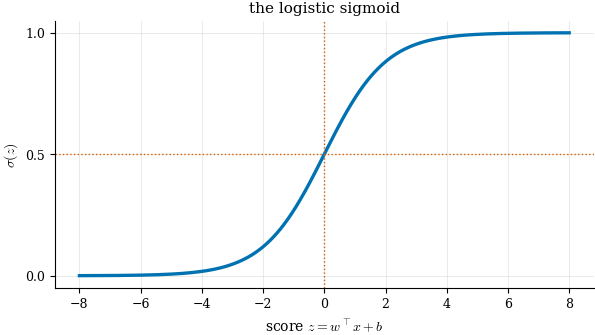

In [3]:
def sigmoid(z):
    "Numerically stable logistic sigmoid, elementwise."
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos, neg = z >= 0, z < 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

z = np.linspace(-8, 8, 400)
print("sigma(0)      =", sigmoid(0.0))
print("symmetry  sigma(-z) == 1 - sigma(z):", np.allclose(sigmoid(-z), 1 - sigmoid(z)))

# derivative check: finite differences vs sigma*(1-sigma)
num = (sigmoid(z + 1e-5) - sigmoid(z - 1e-5)) / 2e-5
ana = sigmoid(z) * (1 - sigmoid(z))
print("derivative  sigma' == sigma*(1-sigma):", np.allclose(num, ana, atol=1e-6))

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.plot(z, sigmoid(z), color="#0072B2", lw=2.4)
ax.axhline(0.5, color="#D55E00", ls=":", lw=1); ax.axvline(0, color="#D55E00", ls=":", lw=1)
ax.set_xlabel("score $z = w^\\top x + b$"); ax.set_ylabel("$\\sigma(z)$")
ax.set_title("the logistic sigmoid"); ax.set_yticks([0, 0.5, 1])
plt.show()

## 3. Odds, log-odds, and why the score *is* the log-odds

A probability $p$ lives in $(0,1)$; a linear score roams over all of $\mathbb{R}$. We bridge the
gap in two steps, each removing a boundary:

* **odds** $\dfrac{p}{1-p}\in(0,\infty)$ &mdash; "how many times more likely than not" (removes the ceiling at 1);
* **log-odds** $\log\dfrac{p}{1-p}\in(-\infty,\infty)$ &mdash; the **logit**, which is unbounded and symmetric.

The logit is the exact inverse of the sigmoid, so if $p=\sigma(z)$ then $\log\frac{p}{1-p}=z$: the
**linear score is the log-odds**. That is *why* logistic regression is a linear model.

logit(sigmoid(z)) == z : True


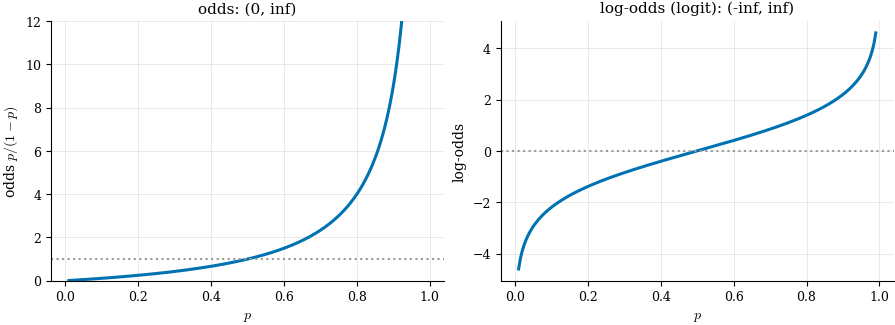

In [4]:
def logit(p):
    "Inverse sigmoid: p in (0,1) -> log-odds."
    p = np.clip(np.asarray(p, float), 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))

zz = np.linspace(-4, 4, 200)
print("logit(sigmoid(z)) == z :", np.allclose(logit(sigmoid(zz)), zz, atol=1e-6))

p = np.linspace(0.01, 0.99, 200)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.0, 3.3))
a1.plot(p, p / (1 - p), color="#0072B2", lw=2.2); a1.axhline(1, color="0.6", ls=":")
a1.set_xlabel("$p$"); a1.set_ylabel("odds $p/(1-p)$"); a1.set_title("odds: (0, inf)"); a1.set_ylim(0, 12)
a2.plot(p, logit(p), color="#0072B2", lw=2.2); a2.axhline(0, color="0.6", ls=":")
a2.set_xlabel("$p$"); a2.set_ylabel("log-odds"); a2.set_title("log-odds (logit): (-inf, inf)")
plt.show()

> 💡 **Intuition (odds ratio).** Because the score is the log-odds, raising a feature $x_j$ by one
> unit adds $w_j$ to the log-odds, which **multiplies the odds** by $e^{w_j}$. So $w_j=0.7$ means
> "each unit of $x_j$ roughly *doubles* the odds" ($e^{0.7}\approx2$). This is how logistic
> coefficients are read in practice.

## 4. One feature: the boundary is a point

With one feature the model is $p=\sigma(wx+b)$. We predict class 1 where $p\ge0.5$, i.e. where
$z=wx+b\ge0$ &mdash; everything to one side of the single point $x^\ast=-b/w$. Let us fit
scikit-learn's `LogisticRegression`, read off $(w,b)$, and mark that boundary point.

true (w, b) = (1.50, -0.60)   fitted (w, b) = (1.18, -0.93)
decision boundary at x* = -b/w = 0.79


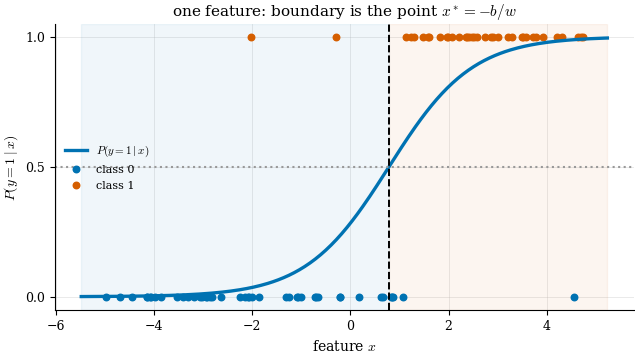

In [5]:
from sklearn.linear_model import LogisticRegression

x, y, w_true, b_true = make_logistic_1d(n=80, seed=3, w=1.5, b=-0.6)
clf = LogisticRegression().fit(x.reshape(-1, 1), y)
w, b = float(clf.coef_[0, 0]), float(clf.intercept_[0])
xstar = -b / w
print(f"true (w, b) = ({w_true:.2f}, {b_true:.2f})   fitted (w, b) = ({w:.2f}, {b:.2f})")
print(f"decision boundary at x* = -b/w = {xstar:.2f}")

xs = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.axvspan(xs.min(), xstar, color="#0072B2", alpha=0.06)
ax.axvspan(xstar, xs.max(), color="#D55E00", alpha=0.06)
ax.plot(xs, sigmoid(w * xs + b), color="#0072B2", lw=2.4, label="$P(y{=}1\\mid x)$")
ax.scatter(x[y == 0], np.zeros((y == 0).sum()), s=22, color="#0072B2", label="class 0")
ax.scatter(x[y == 1], np.ones((y == 1).sum()), s=22, color="#D55E00", label="class 1")
ax.axhline(0.5, color="0.6", ls=":"); ax.axvline(xstar, color="black", ls="--", lw=1.4)
ax.set_xlabel("feature $x$"); ax.set_ylabel("$P(y{=}1\\mid x)$"); ax.set_yticks([0, 0.5, 1])
ax.set_title("one feature: boundary is the point $x^*=-b/w$"); ax.legend(fontsize=8, loc="center left")
plt.show()

## 5. Two features: the boundary is a line

Add a second feature and the boundary $z=w_1x_1+w_2x_2+b=0$ becomes a **straight line** in the
plane, splitting it into a "predict 1" and a "predict 0" region. The shading below is the model's
probability $P(y{=}1\mid\mathbf{x})=\sigma(z)$ &mdash; a smooth ramp, not a hard cut &mdash; and the black
line is its $0.5$ level set.

true w = [ 1.8 -2. ],  b = 0.40
fit  w = [1.56 -2.08], b = 0.20


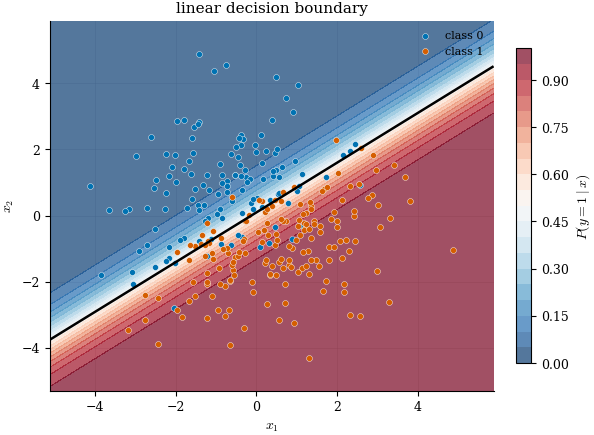

In [6]:
X, y, w_true, b_true = make_logistic_2d(n=300, seed=2, w=(1.8, -2.0), b=0.4)
clf = LogisticRegression().fit(X, y)
w1, w2 = clf.coef_[0]; b = float(clf.intercept_[0])
print(f"true w = {w_true},  b = {b_true:.2f}")
print(f"fit  w = [{w1:.2f} {w2:.2f}], b = {b:.2f}")

# probability shading over a grid
pad = 1.0
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-pad, X[:, 0].max()+pad, 300),
                     np.linspace(X[:, 1].min()-pad, X[:, 1].max()+pad, 300))
prob = sigmoid(w1 * xx + w2 * yy + b)

fig, ax = plt.subplots(figsize=(6.0, 4.4))
cf = ax.contourf(xx, yy, prob, levels=20, cmap="RdBu_r", alpha=0.7)
ax.contour(xx, yy, prob, levels=[0.5], colors="black", linewidths=1.8)
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=18, color="#0072B2", edgecolor="white", lw=0.3, label="class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=18, color="#D55E00", edgecolor="white", lw=0.3, label="class 1")
fig.colorbar(cf, ax=ax, shrink=0.85, label="$P(y{=}1\\mid x)$")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title("linear decision boundary")
ax.legend(fontsize=8, loc="upper right")
plt.show()

> 🔬 **Going deeper (why linear).** The boundary is $\{\mathbf{x}:\sigma(z)=0.5\}$. Since $\sigma$ is
> strictly increasing and $\sigma(0)=0.5$, that set is exactly $\{\mathbf{x}:z=0\}$ &mdash; the zero
> level set of the *linear* function $z=\mathbf{w}^\top\mathbf{x}+b$, i.e. a hyperplane (a line in
> 2-D, a plane in 3-D). Slicing the curved probability surface at the single height $0.5$ collapses
> the sigmoid and leaves the flat equation $z=0$ behind.

## 6. The whole model is one "neuron"

Putting it together: weighted sum, then sigmoid. That is the entire forward computation &mdash; the
single building block that, stacked and repeated, becomes a neural network later in the course.

In [7]:
def logistic_predict_proba(X, w, b):
    "Forward pass: z = X w + b, then squash. Returns P(y=1|x)."
    return sigmoid(X @ np.asarray(w) + b)

def logistic_predict(X, w, b, threshold=0.5):
    return (logistic_predict_proba(X, w, b) >= threshold).astype(int)

# check our from-scratch forward pass matches sklearn's
p_scratch = logistic_predict_proba(X, [w1, w2], b)
p_sklearn = clf.predict_proba(X)[:, 1]
print("our P(y=1|x) matches sklearn:", np.allclose(p_scratch, p_sklearn))
print("our labels match sklearn    :", np.array_equal(logistic_predict(X, [w1, w2], b), clf.predict(X)))
print("training accuracy           :", (logistic_predict(X, [w1, w2], b) == y).mean().round(3))

our P(y=1|x) matches sklearn: True
our labels match sklearn    : True
training accuracy           : 0.893


## Recap & exercises

**Recap.**
* A straight line cannot be a probability (it escapes $[0,1]$); the **sigmoid** $\sigma(z)=1/(1+e^{-z})$ squashes any score into $(0,1)$.
* Key facts: $\sigma(0)=\tfrac12$, $\sigma(-z)=1-\sigma(z)$, $\sigma'=\sigma(1-\sigma)$; use the **stable** implementation.
* The **log-odds** (logit) is the inverse of the sigmoid, so the linear score **is** the log-odds &mdash; and $e^{w_j}$ is the **odds ratio** per unit of $x_j$.
* Predicting = thresholding $p$ at $0.5$ = asking the **sign of $z$**, so the **decision boundary is linear**: a point (1 feature), a line (2), a hyperplane (more).
* The model is one **neuron**: a weighted sum followed by the sigmoid.

**Exercises.**
1. In Section&nbsp;4, change the true slope to `w=4.0` (steeper). Does the sigmoid get sharper, and does the boundary point $x^\ast$ move?
2. Use `make_logistic_2d(..., w=(2.0, 0.0))`. What is special about the boundary line when $w_2=0$? (Hint: solve $w_1x_1+b=0$.)
3. Read the fitted coefficients as **odds ratios** ($e^{w_j}$). Which feature multiplies the odds more per unit?
4. Add a nonlinear feature $x_1^2$ to `X` (a third column) and refit. Is the boundary still a straight line in the *original* $(x_1,x_2)$ plane? Why does adding features change its shape?
5. Lower the classification threshold to $0.3$ in `logistic_predict`. How does the "predict 1" region grow? (We return to thresholds in 04c.)

*Next:* **04b &mdash; training from scratch**: the cross-entropy loss, its gradient
$\tfrac1n\mathbf{X}^\top(\mathbf{p}-\mathbf{y})$, and gradient descent &mdash; recovering these same coefficients.